In [1]:
import pandas as pd
import json
from analysis_utils import (
    construct_bias_variants, 
    z_test,
    mcnemar_test,
    convert_to_cometkiwi_input
    )

In [2]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import FuncFormatter
import numpy as np
from pathlib import Path
from scipy.stats import norm

class ScorePlotter:
    def __init__(self, alpha=0.05):
        """
        Initializes the plotter with shared test constraints and baseline scores.
        """
        self.alpha = alpha

    def _build_score_entry(self, name, score, critical, reject, plot_label):
        """Helper to uniformly format the dataset dictionaries for the plotter."""
        return {
            'score': score,
            'critical': critical,
            'reject H0': reject,
            'label': plot_label
        }

    def get_z_scores(self, triples_list, label, language='de', convert_to_p=False, rtt=False):
        """
        Processes Z-tests and returns the score dictionaries.
        triples_list: List[Tuple(df, biased_sets, plot_label)]
        """
        if not isinstance(triples_list, list):
            triples_list = [triples_list]

        scores_list = []    # List[dict]
        for df, biased_sets, plot_label in triples_list:

            natives = df[(df['language'] == language) & (df['label'] == label)]['comment_pred']
            scores = {}
            
            for j, (name, dataset) in enumerate(biased_sets.items()):
                translations = dataset['rtt_pred'] if rtt else dataset['translation_pred']

                z, critical, reject = z_test(
                    population1=natives,
                    population2=translations,
                    label=label,
                    alpha=self.alpha
                )

                score = norm.sf(z) if convert_to_p else z
                crit = self.alpha if convert_to_p else critical

                scores[name] = self._build_score_entry(
                    name, score, crit, reject, plot_label
                )

            scores_list.append(scores)

        return scores_list

    def get_mcnemar_scores(self, tuples_list, rtt=False):
        """
        Processes McNemar tests and returns the score dictionaries.
        tuples_list: List[Tuple(biased_sets, plot_label)]
        """
        if not isinstance(tuples_list, list):
            tuples_list = [tuples_list]

        scores_list = []  # List[dict]
        for biased_sets, plot_label in tuples_list:

            scores = {}
            for j, (name, dataset) in enumerate(biased_sets.items()):
                B = dataset['comment_pred']                                     # (B)efore transformation
                A = dataset['rtt_pred'] if rtt else dataset['translation_pred'] # (A)fter transformation
                Y = dataset['label']                                            # Gold Labels

                p_value, _, significant = mcnemar_test(B, A, Y, alpha=self.alpha)

                scores[name] = self._build_score_entry(
                    name, p_value, self.alpha, significant, plot_label
                )

            scores_list.append(scores)

        return scores_list

    def plot(self, scores, ck_scores={}, bleu_scores={}, mode='p', normalize_scale=(None, None), log_scale=False, separate_ax=False, save=None):
        """The core Matplotlib generation engine."""
        if not isinstance(scores, list):
            scores = [scores]
        
        bias_pct = [score.split('_')[-1] for score in scores[0].keys()]
        threshold = [val['critical'] for val in scores[0].values()][0] 

        fig, ax = plt.subplots(figsize=(4, 4))
        ax2 = None

        if log_scale:
            ax.set_yscale('log')

        ax.axhline(threshold, color='gray', linestyle='--')
        total_y_min, total_y_max = 100, 0
        pad = 0.3 if mode == 'z' else 0.09

        num_scores = len(scores) + 1
        purples = [cm.Purples(p) for i, p in enumerate(np.linspace(0, 1, num_scores)) if i != 0]

        for i, scores_dict in enumerate(scores):
            bias_color = 'black' if i == 0 else purples[i]
            bias_scores = [val['score'] for val in scores_dict.values()]
            label = [val['label'] for val in scores_dict.values()][0]
            
            ax.plot(bias_pct, bias_scores, color=bias_color, marker='o', label=label)
            
            y_min = min(bias_scores + [threshold]) - pad
            y_max = max(bias_scores + [threshold]) + pad
            total_y_min = min(y_min, total_y_min)
            total_y_max = max(y_max, total_y_max)

        # CometKiwi scores
        if ck_scores:
            ax2 = ax.twinx() if not ax2 else ax2
            ax2.plot(bias_pct, ck_scores.values(), color='darkgreen', marker='s', label="CometKiwi")
            ax2.set_ylabel('CometKiwi', color='darkgreen')
            ax2.tick_params(axis='y', labelcolor='darkgreen')
            ax2.yaxis.set_major_formatter('{x:.2f}')
            if normalize_scale[0] is not None:
                ax2.set_ylim(0.7, 0.9)

        # BLEU scores
        if bleu_scores:
            ax2 = ax.twinx() if not ax2 else ax2
            ax2.plot(bias_pct, bleu_scores.values(), color='#2242c7', marker='s', label="BLEU")
            ax2.set_ylabel('BLEU', color='#2242c7')
            ax2.tick_params(axis='y', labelcolor='#2242c7')
            if normalize_scale[0] is not None:
                ax2.set_ylim(30, 50)

        ax.tick_params(axis='y', color='black')
        ax.set_xlabel('% of injected bias', labelpad=15)
        
        y_label = 'Z score' if mode == 'z' else 'p-value'
        if log_scale:
            y_label += ' (log scale)'
        ax.set_ylabel(y_label, color='black')
        
        min_y, max_y = normalize_scale
        total_y_min = min_y - pad if min_y is not None else total_y_min
        if log_scale:
            total_y_max = max_y + (pad * 10) if max_y else total_y_max
        else:
            total_y_max = max_y + pad if max_y else total_y_max
            
        ax.set_ylim(total_y_min, total_y_max)
        
        # Threshold logic
        reject_bounds = (threshold, total_y_max) if mode == 'z' else (total_y_min, threshold)
        accept_bounds = (total_y_min, threshold) if mode == 'z' else (threshold, total_y_max)
        
        ax.axhspan(*accept_bounds, facecolor='lightcoral', alpha=0.3)
        ax.axhspan(*reject_bounds, facecolor='lightgreen', alpha=0.3)
        
        offset = 0.1 if mode == 'z' else 0.01
        x_pos = bias_pct[0]
        
        ax.text(x_pos, threshold + offset if mode == 'z' else threshold - offset, 'Reject H₀',
                ha='left', va='bottom' if mode == 'z' else 'top', fontsize=10, color='darkgreen')
        ax.text(x_pos, threshold - offset if mode == 'z' else threshold + offset, 'Fail to Reject H₀',
                ha='left', va='top' if mode == 'z' else 'bottom', fontsize=10, color='darkred')

        if ax2:
            handles1, labels1 = ax.get_legend_handles_labels()
            handles2, labels2 = ax2.get_legend_handles_labels()
            ax.legend(handles1 + handles2, labels1 + labels2, fontsize=9)
        else:
            ax.legend(fontsize=9)
        
        if save:
            Path(save).parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save, dpi=600, bbox_inches='tight')
            print(f"Figure saved to {save}")
        
        plt.show()

---
### EuroLLM-9B translations

In [3]:
column_order = ['id', 'source', 'target', 'comment', 'language', 'label', 'target_lang', 'transformation', 'translation', 'rtt', 'comment_pred', 'transformation_pred', 'translation_pred', 'rtt_pred']

xstance_path = "../5.1/predictions/{classifier}/xstance_preds.csv"
biased_path = "../5.1/predictions/{classifier}/biased/fr2de2fr_preds.csv"
neutral_path = "../5.1/predictions/{classifier}/neutral/fr2de2fr_preds.csv"

# Predictions from `xlmr+xstance`
xstance_xlmr_xstance = pd.read_csv(xstance_path.format(classifier="xlmr+xstance"))
biased_xlmr_xstance = pd.read_csv(biased_path.format(classifier="xlmr+xstance"))[column_order]
neutral_xlmr_xstance = pd.read_csv(neutral_path.format(classifier="xlmr+xstance"))
neutral_xlmr_xstance['transformation_pred'] = float('nan')
neutral_xlmr_xstance = neutral_xlmr_xstance[column_order]
pos_sets_xlmr_xstance, neg_sets_xlmr_xstance = construct_bias_variants(biased_xlmr_xstance, neutral_xlmr_xstance)

# Predictions from `xlmr+bimultisd`
xstance_xlmr_bimultisd = pd.read_csv(xstance_path.format(classifier="xlmr+bimultisd"))
biased_xlmr_bimultisd = pd.read_csv(biased_path.format(classifier="xlmr+bimultisd"))[column_order]
neutral_xlmr_bimultisd = pd.read_csv(neutral_path.format(classifier="xlmr+bimultisd"))
neutral_xlmr_bimultisd['transformation_pred'] = float('nan')
neutral_xlmr_bimultisd = neutral_xlmr_bimultisd[column_order]
pos_sets_xlmr_bimultisd, neg_sets_xlmr_bimultisd = construct_bias_variants(biased_xlmr_bimultisd, neutral_xlmr_bimultisd)

# Predictions from `llama+bimultisd`
xstance_llama_bimultisd = pd.read_csv(xstance_path.format(classifier="llama+bimultisd"))
biased_llama_bimultisd = pd.read_csv(biased_path.format(classifier="llama+bimultisd"))[column_order]
neutral_llama_bimultisd = pd.read_csv(neutral_path.format(classifier="llama+bimultisd"))
neutral_llama_bimultisd['transformation_pred'] = float('nan')
neutral_llama_bimultisd = neutral_llama_bimultisd[column_order]
pos_sets_llama_bimultisd, neg_sets_llama_bimultisd = construct_bias_variants(biased_llama_bimultisd, neutral_llama_bimultisd)

# Predictions from `llama+bimultisdxlt`
xstance_llama_bimultisdxlt = pd.read_csv(xstance_path.format(classifier="llama+bimultisdxlt"))
biased_llama_bimultisdxlt = pd.read_csv(biased_path.format(classifier="llama+bimultisdxlt"))[column_order]
neutral_llama_bimultisdxlt = pd.read_csv(neutral_path.format(classifier="llama+bimultisdxlt"))
neutral_llama_bimultisdxlt['transformation_pred'] = float('nan')
neutral_llama_bimultisdxlt = neutral_llama_bimultisdxlt[column_order]
pos_sets_llama_bimultisdxlt, neg_sets_llama_bimultisdxlt = construct_bias_variants(biased_llama_bimultisdxlt, neutral_llama_bimultisdxlt)

---
###

In [4]:
plotter = ScorePlotter(alpha=0.05)

---
### **Two-proportion Z-test** results for all classifier variants (Figure 3b of Paper)

In [5]:
z_pos_group = [
    (xstance_llama_bimultisd, pos_sets_llama_bimultisd, 'llama+bimultisd'),
    (xstance_llama_bimultisdxlt, pos_sets_llama_bimultisdxlt, 'llama+bimultisdxlt'),
    (xstance_xlmr_bimultisd, pos_sets_xlmr_bimultisd, 'xlmr+bimultisd'),
    (xstance_xlmr_xstance, pos_sets_xlmr_xstance, 'xlmr+xstance'),
]

z_neg_group = [
    (xstance_llama_bimultisd, neg_sets_llama_bimultisd, 'llama+bimultisd'),
    (xstance_llama_bimultisdxlt, neg_sets_llama_bimultisdxlt, 'llama+bimultisdxlt'),
    (xstance_xlmr_bimultisd, neg_sets_xlmr_bimultisd, 'xlmr+bimultisd'),
    (xstance_xlmr_xstance, neg_sets_xlmr_xstance, 'xlmr+xstance'),
]

Figure saved to ../img/z_direct_pos.png


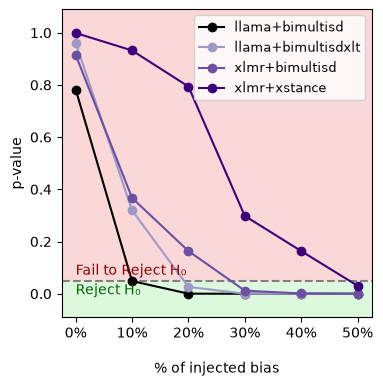

Figure saved to ../img/z_direct_neg.png


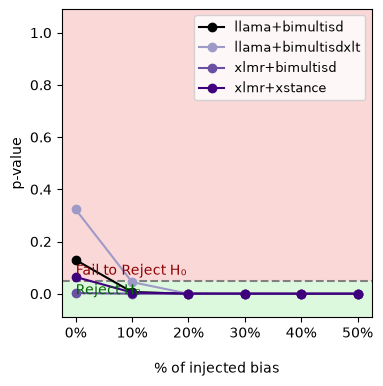

In [6]:
# Direct MT - Gold Label: 'FAVOR'
z_direct_pos = plotter.get_z_scores(
    z_pos_group, 
    'FAVOR', 
    language='de', 
    convert_to_p=True, 
    rtt=False 
    ) 
plotter.plot(z_direct_pos, normalize_scale=(0, 1), save='../img/z_direct_pos.png')

# Direct MT - Gold Label: 'AGAINST'
z_direct_neg = plotter.get_z_scores(
    z_neg_group, 
    'AGAINST', 
    language='de', 
    convert_to_p=True, 
    rtt=False
    )
plotter.plot(z_direct_neg, normalize_scale=(0, 1), save='../img/z_direct_neg.png')


Figure saved to ../img/z_rtt_pos.png


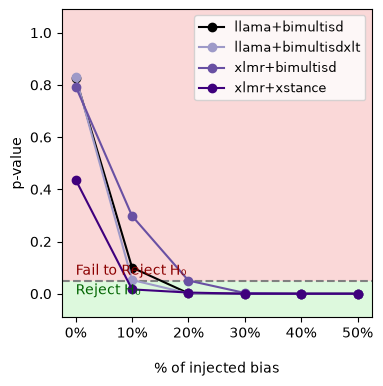

Figure saved to ../img/z_rtt_neg.png


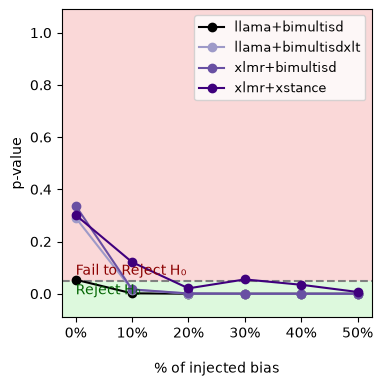

In [7]:
# RTT (fr-->de-->fr) - Gold Label: 'FAVOR'
z_rtt_pos = plotter.get_z_scores(
    z_pos_group, 
    'FAVOR', 
    language='fr', 
    convert_to_p=True, 
    rtt=True, 
    ) 
plotter.plot(z_rtt_pos, normalize_scale=(0, 1), save='../img/z_rtt_pos.png')

# RTT (fr-->de-->fr) - Gold Label: 'AGAINST'
z_rtt_neg = plotter.get_z_scores(
    z_neg_group, 
    'AGAINST', 
    language='fr', 
    convert_to_p=True, 
    rtt=True
    )
plotter.plot(z_rtt_neg, normalize_scale=(0, 1), save='../img/z_rtt_neg.png')

---
### **McNemar's Test** results for all classifier variants

In [8]:
mcnemar_pos_group = [
    (pos_sets_llama_bimultisd, 'llama+bimultisd'),
    (pos_sets_llama_bimultisdxlt, 'llama+bimultisdxlt'),
    (pos_sets_xlmr_bimultisd, 'xlmr+bimultisd'),
    (pos_sets_xlmr_xstance, 'xlmr+xstance'),
]

mcnemar_neg_group = [
    (neg_sets_llama_bimultisd, 'llama+bimultisd'),
    (neg_sets_llama_bimultisdxlt, 'llama+bimultisdxlt'),
    (neg_sets_xlmr_bimultisd, 'xlmr+bimultisd'),
    (neg_sets_xlmr_xstance, 'xlmr+xstance'),
]

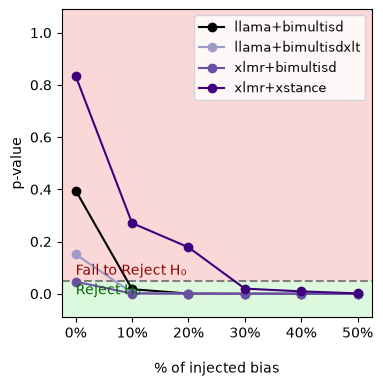

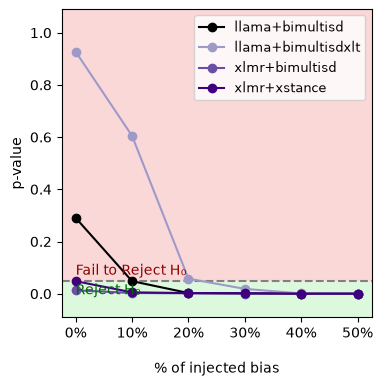

In [9]:
# Direct MT - Gold Label: 'FAVOR'
mcnemar_direct_pos = plotter.get_mcnemar_scores(mcnemar_pos_group, rtt=False)
plotter.plot(mcnemar_direct_pos, normalize_scale=(0, 1)) # save='../img/mcnemar_direct_pos.pdf'

# Direct MT - Gold Label: 'AGAINST'
mcnemar_direct_neg = plotter.get_mcnemar_scores(mcnemar_neg_group, rtt=False) 
plotter.plot(mcnemar_direct_neg, normalize_scale=(0, 1)) # save='../img/mcnemar_direct_neg.pdf'

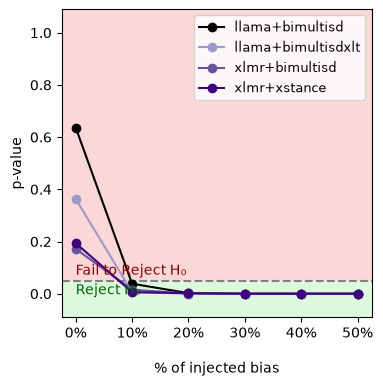

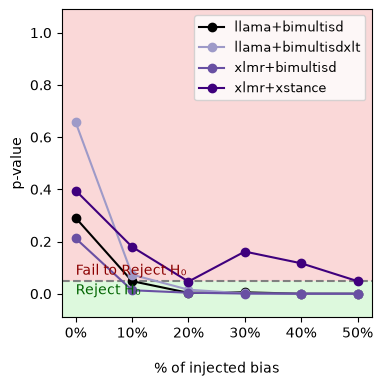

In [10]:
# RTT (fr-->de-->fr) - Gold Label: 'FAVOR'
mcnemar_rtt_pos = plotter.get_mcnemar_scores(mcnemar_pos_group, rtt=True)
plotter.plot(mcnemar_rtt_pos, normalize_scale=(0, 1)) # save='../img/mcnemar_rtt_pos.pdf'

# RTT (fr-->de-->fr) - Gold Label: 'AGAINST'
mcnemar_rtt_neg = plotter.get_mcnemar_scores(mcnemar_neg_group, rtt=True) 
plotter.plot(mcnemar_rtt_neg, normalize_scale=(0, 1)) # save='../img/mcnemar_rtt_neg.pdf'

---
### Comparison with BLEU & CometKiwi

Classifier: `llama+bimultisd`

To compute the COMETKiwi and BLEU scores, it is sufficient to use the source texts and translations/RTTs from the bias variants in any one of the prediction files, since the translations are identical across files and only the predictions differ.

In [ ]:
for name, df in pos_sets_llama_bimultisd.items():
    convert_to_cometkiwi_input(df, src_col="comment", mt_col="translation", save_dir="../5.1/COMETKiwi/inputs/favor", filename=name)

Data written to ../5.1/COMETKiwi/inputs/favor/bias_0%
Data written to ../5.1/COMETKiwi/inputs/favor/bias_10%
Data written to ../5.1/COMETKiwi/inputs/favor/bias_20%
Data written to ../5.1/COMETKiwi/inputs/favor/bias_30%
Data written to ../5.1/COMETKiwi/inputs/favor/bias_40%
Data written to ../5.1/COMETKiwi/inputs/favor/bias_50%


In [13]:
for name, df in neg_sets_llama_bimultisd.items():
    convert_to_cometkiwi_input(df, src_col="comment", mt_col="translation", save_dir="../5.1/COMETKiwi/inputs/against", filename=name)

Data written to ../5.1/COMETKiwi/inputs/against/bias_0%
Data written to ../5.1/COMETKiwi/inputs/against/bias_10%
Data written to ../5.1/COMETKiwi/inputs/against/bias_20%
Data written to ../5.1/COMETKiwi/inputs/against/bias_30%
Data written to ../5.1/COMETKiwi/inputs/against/bias_40%
Data written to ../5.1/COMETKiwi/inputs/against/bias_50%


Here, you will need to run `src/cometkiwi.py` to generate the COMETKiwi scores for the bias variants.

Example:
```
python src/cometkiwi.py \
--model_path Unbabel/wmt22-cometkiwi-da \
--data_dir 5.1/COMETKiwi/inputs \
--save_dir 5.1/COMETKiwi/results \
--save_indiv_scores
```

In [20]:
z_pos = [(xstance_llama_bimultisd, pos_sets_llama_bimultisd, 'Z (converted)')]
z_neg = [(xstance_llama_bimultisd, neg_sets_llama_bimultisd, 'Z (converted)')]

mcnemar_pos = [(pos_sets_llama_bimultisd, 'McNemar')]
mcnemar_neg = [(neg_sets_llama_bimultisd, 'McNemar')]

cometkiwi_pos = json.load(open('../translations/EuroLLM/biased/9B/favor-llama3b/system_scores/0-50%.json'))
cometkiwi_neg = json.load(open('../translations/EuroLLM/biased/9B/against-llama3b/system_scores/0-50%.json'))

FileNotFoundError: [Errno 2] No such file or directory: '../translations/EuroLLM/biased/9B/favor-llama3b/system_scores/0-50%.json'

In [14]:
from analysis_modules import compute_bleu

def get_bleu(biased_sets):
    bleu = {}
    for bias_pct, df in biased_sets.items():
        corpus_bleu, sent_bleus = compute_bleu(
            df['comment'].tolist(), 
            df['rtt'].tolist()
        )
        bleu[bias_pct] = corpus_bleu
    return bleu

bleu_pos = get_bleu(pos_sets_llama_bimultisd)
bleu_neg = get_bleu(neg_sets_llama_bimultisd)

Figure saved to ../img/mcnemar_direct_pos.png


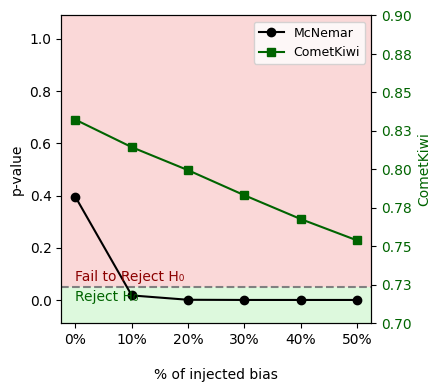

Figure saved to ../img/mcnemar_direct_neg.png


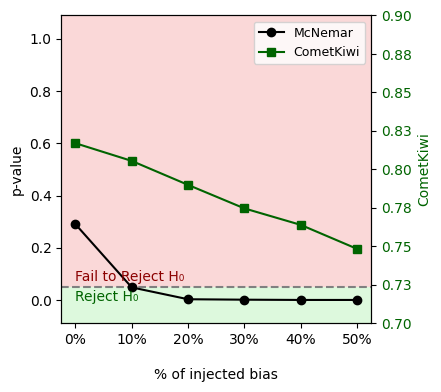

In [ ]:
# Direct MT - Gold Label: 'FAVOR'
z_direct_pos = plotter.get_z_scores(
    z_pos, 'FAVOR', language='de', convert_to_p=True, rtt=False 
    )
mcnemar_direct_pos = plotter.get_mcnemar_scores(mcnemar_pos, rtt=False)
direct_pos = z_direct_pos + mcnemar_direct_pos
plotter.plot(direct_pos, ck_scores=cometkiwi_pos, normalize_scale=(0, 1), save='../img/calib_direct_pos.png')

# Direct MT - Gold Label: 'AGAINST'
z_direct_neg = plotter.get_z_scores(
    z_neg, 'AGAINST', language='de', convert_to_p=True, rtt=False
    )
mcnemar_direct_neg = plotter.get_mcnemar_scores(mcnemar_neg, rtt=False) 
direct_neg = z_direct_neg + mcnemar_direct_neg
plotter.plot(direct_neg, ck_scores=cometkiwi_neg, normalize_scale=(0, 1), save='../img/calib_direct_neg.png')

Figure saved to ../img/mcnemar_rtt_pos.png


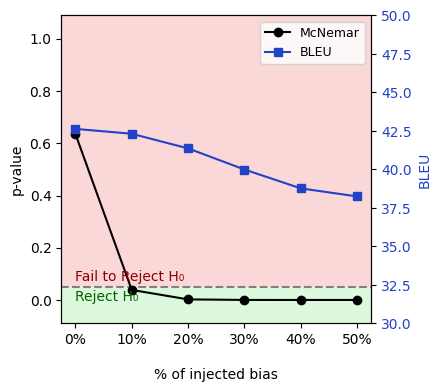

Figure saved to ../img/mcnemar_rtt_neg.png


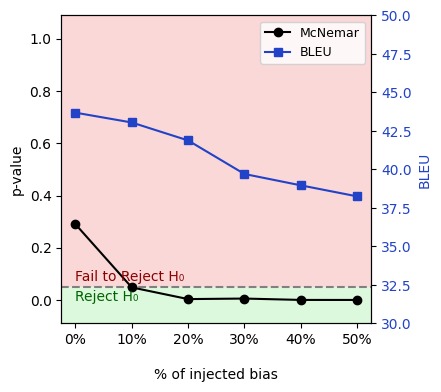

In [ ]:
# RTT (fr-->de-->fr) - Gold Label: 'FAVOR'
z_rtt_pos = plotter.get_z_scores(
    z_pos, 'FAVOR', language='fr', convert_to_p=True, rtt=True 
    )
mcnemar_rtt_pos = plotter.get_mcnemar_scores(mcnemar_pos, rtt=True)
rtt_pos = z_rtt_pos + mcnemar_rtt_pos
plotter.plot(rtt_pos, bleu_scores=bleu_pos, normalize_scale=(0, 1), save='../img/calib_rtt_pos.png')

# RTT (fr-->de-->fr) - Gold Label: 'AGAINST'
z_rtt_neg = plotter.get_z_scores(
    z_neg, 'AGAINST', language='fr', convert_to_p=True, rtt=True
    )
mcnemar_rtt_neg = plotter.get_mcnemar_scores(mcnemar_neg, rtt=True) 
rtt_neg = z_rtt_neg + mcnemar_rtt_neg
plotter.plot(rtt_neg, bleu_scores=bleu_neg, normalize_scale=(0, 1), save='../img/calib_rtt_neg.png')